In [ ]:
!pip install requests beautifulsoup4 pandas numpy matplotlib plotly selenium streamlit
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
def scrape_static_pricing(url, company_name):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    data = []

    pricing_cards = soup.find_all("div", class_="pricing-card")

    for card in pricing_cards:
        try:
            plan = card.find("h3").text.strip()
            price = card.find("span", class_="price").text.strip()
            features = [li.text.strip() for li in card.find_all("li")]

            data.append({
                "company": company_name,
                "plan": plan,
                "price": price,
                "features": ", ".join(features)
            })
        except:
            continue

    return pd.DataFrame(data)

In [3]:
data = {
    "company": ["A","A","B","B","C","C"],
    "plan": ["Basic","Pro","Starter","Business","Lite","Premium"],
    "price": ["$10","$30","$15","$45","$8","$60"],
    "features": [
        "Feature1, Feature2",
        "Feature1, Feature2, Feature3, Feature4",
        "Feature1, Feature2, Feature3",
        "Feature1, Feature2, Feature3, Feature4, Feature5",
        "Feature1",
        "Feature1, Feature2, Feature3, Feature4, Feature5, Feature6"
    ]
}

df = pd.DataFrame(data)
df

,company,plan,price,features
0,A,Basic,$10,"Feature1, Feature2"
1,A,Pro,$30,"Feature1, Feature2, Feature3, Feature4"
2,B,Starter,$15,"Feature1, Feature2, Feature3"
3,B,Business,$45,"Feature1, Feature2, Feature3, Feature4, Feature5"
4,C,Lite,$8,Feature1
5,C,Premium,$60,"Feature1, Feature2, Feature3, Feature4, Featur..."


Data Cleaning

In [4]:
def clean_price(price):
    return float(price.replace("$", "").replace("/month", ""))

df["price_numeric"] = df["price"].apply(clean_price)
df["feature_count"] = df["features"].apply(lambda x: len(x.split(",")))
df

,company,plan,price,features,price_numeric,feature_count
0,A,Basic,$10,"Feature1, Feature2",10.0,2
1,A,Pro,$30,"Feature1, Feature2, Feature3, Feature4",30.0,4
2,B,Starter,$15,"Feature1, Feature2, Feature3",15.0,3
3,B,Business,$45,"Feature1, Feature2, Feature3, Feature4, Feature5",45.0,5
4,C,Lite,$8,Feature1,8.0,1
5,C,Premium,$60,"Feature1, Feature2, Feature3, Feature4, Featur...",60.0,6


Feature Engineering

In [5]:
df["tier"] = pd.cut(
    df["price_numeric"],
    bins=[0, 15, 35, 60, 1000],
    labels=["Low", "Mid", "High", "Premium"]
)
df["value_score"] = df["feature_count"] / df["price_numeric"]

df["price_zscore"] = (df["price_numeric"] - df["price_numeric"].mean()) / df["price_numeric"].std()
df

,company,plan,price,features,price_numeric,feature_count,tier,value_score,price_zscore
0,A,Basic,$10,"Feature1, Feature2",10.0,2,Low,0.200000,-0.856173
1,A,Pro,$30,"Feature1, Feature2, Feature3, Feature4",30.0,4,Mid,0.133333,0.095130
2,B,Starter,$15,"Feature1, Feature2, Feature3",15.0,3,Low,0.200000,-0.618347
3,B,Business,$45,"Feature1, Feature2, Feature3, Feature4, Feature5",45.0,5,High,0.111111,0.808608
4,C,Lite,$8,Feature1,8.0,1,Low,0.125000,-0.951303
5,C,Premium,$60,"Feature1, Feature2, Feature3, Feature4, Featur...",60.0,6,High,0.100000,1.522085


Competitive Metrics

In [6]:
company_summary = df.groupby("company").agg({
    "price_numeric": "mean",
    "feature_count": "mean",
    "value_score": "mean"
}).reset_index()

company_summary.columns = ["company", "avg_price", "avg_features", "avg_value"]

company_summary

,company,avg_price,avg_features,avg_value
0,A,20.0,3.0,0.166667
1,B,30.0,4.0,0.155556
2,C,34.0,3.5,0.112500


Pricing Comparison Chart

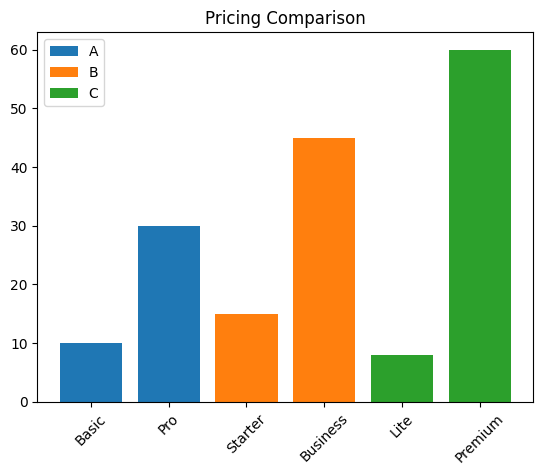

In [7]:
for company in df["company"].unique():
    subset = df[df["company"] == company]
    plt.bar(subset["plan"], subset["price_numeric"], label=company)

plt.legend()
plt.title("Pricing Comparison")
plt.xticks(rotation=45)
plt.show()

Value vs Price Scatter Plot

In [8]:
fig = px.scatter(
    df,
    x="price_numeric",
    y="feature_count",
    color="company",
    size="value_score",
    hover_data=["plan"]
)

fig.show()

Market Position Map

In [9]:
fig = px.scatter(
    company_summary,
    x="avg_price",
    y="avg_features",
    text="company",
    size="avg_value"
)

fig.update_traces(textposition="top center")
fig.show()

In [10]:
df.to_csv("competitor_data.csv", index=False)
company_summary.to_csv("company_summary.csv", index=False)